## **Proyecto de Machine Learning: nomadismo digital y coste de vida global**

**Enfoque estratégico:** Clustering de ciudades como destino nómada digital & Regresión para predecir el score nómada de países en función de las variables. 

**Autores:** Daniela Aguirre, Agustín Arganín y Juan F. Cía

**Base del proyecto:** [EDA Nomadismo Digital](https://github.com/juanfcia/EDA-Nomadismo-Digital)

**Datasets y registros:**
1. **Registros:** 4,742 ciudades y 85 países. 
2. **Datasets:** [Variables agregadas](https://github.com/danielaaguirrej55-source/Proyecto-ML---Machine-Learning/blob/proj_ml_juanfcia/src/data_sample/cost-of-living-variables-agregadas.csv), [Mapa de variables](https://github.com/danielaaguirrej55-source/Proyecto-ML---Machine-Learning/blob/proj_ml_juanfcia/src/data_sample/cost-of-living-vars-map.csv), [Digital Nomad Index Circleloop](https://github.com/danielaaguirrej55-source/Proyecto-ML---Machine-Learning/blob/proj_ml_juanfcia/src/data_sample/digital-nomad-index-cicleloop-clean.csv) y [Digital Nomad Index Movingto](https://github.com/danielaaguirrej55-source/Proyecto-ML---Machine-Learning/blob/proj_ml_juanfcia/src/data_sample/digital-nomad-index-movingto-clean.csv).  
3. **Hipótesis validadas en el proyecto del EDA:** 9 hipótesis validadas

### **Problema de negocio**

#### **Contexto**

El nomadismo digital es un fenómeno creciente: profesionales que trabajan en remoto desde cualquier lugar del mundo. Elegir destino implica evaluar decenas de factores — coste de vida, conectividad, seguridad, calidad de vida — que interactúan de forma no lineal.

#### **Preguntas de negocio**

1. ¿Qué factores de coste de vida, conectividad y bienestar determinan el atractivo de un destino para nómadas digitales? 
2. ¿Podemos segmentar las ciudades del mundo en perfiles nómadas y predecir el score de un país?*

#### **Hallazgos del EDA que motivan este proyecto**

| Hallazgo | Estadístico | Implicación ML |
|---|---|---|
| **Conectividad** = predictor #1 del score nómada | r=0.73, p<0.001 | Feature de alta importancia |
| **Bienestar social** correlaciona fuertemente | r=0.70, p<0.001 | Feature de alta importancia |O
| **Los mejores destinos son más caros** | Top 20% coste mayor | Relación no lineal con el score |
| **Alimentación** pesa más que vivienda | Hipótesis rechada | Validar con feature importance |
| **Seguridad no tiene correlación fuerte** | r=0.18, p>0.05 | Variable de baja importancia |
| **Outliers value for money** identificados | Bajo coste + alto score | ¿Forman un clúster propio? |

#### **Enfoque estratético del proyecto**

Pipeline híbrido en 3 fases:

1. **Fase 1 — Clustering (aprendizaje no supervisado):** Segmentar 4,742 ciudades en perfiles nómadas usando 7 índices de coste de vida.
2. **Fase 2 — Regresión (aprendizaje supervisado):** Predecir el `digital_nomad_score` de 81 países usando indicadores de coste, conectividad, bienestar y los perfiles de cluster descubiertos en la fase 1.
3. **Fase 3 - Iteación añadiendo nuevos datos y ver variabilidad predictora:** Incluir datos de series temporales sobre inflación, ingresos por turismo, precio de la vivienda, clima... y analizar si los modelos baseline de fases 1 y 2 modifican su comportamiento para negocio. 

### **Carga de librerías y de datasets iniciales**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Sklearn - Preprocesado
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.feature_selection import SelectKBest, f_regression

# Sklearn - Clustering
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

# Sklearn - Regresión
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# Guardado del modelo
import joblib

import warnings
warnings.filterwarnings('ignore')

In [3]:
# Carga de datasets limpios del EDA

df_cities = pd.read_csv('../data_sample/cost-of-living-variables-agregadas.csv')
df_circleloop = pd.read_csv('../data_sample/digital-nomad-index-cicleloop-clean.csv')
df_movingto = pd.read_csv('../data_sample/digital-nomad-index-movingto-clean.csv')

In [4]:
# Número de registros y variables por cada uno de los datasets

print(f'Dataset 1: Cost of Living -> {df_cities.shape[0]} ciudades y {df_cities.shape[1]} variables')
print(f'Dataset 2: Circleloop -> {df_circleloop.shape[0]} países y {df_circleloop.shape[1]} variables')
print(f'Dataset 3: Movingto -> {df_movingto.shape[0]} países y {df_movingto.shape[1]} variables')

Dataset 1: Cost of Living -> 4742 ciudades y 65 variables
Dataset 2: Circleloop -> 85 países y 10 variables
Dataset 3: Movingto -> 40 países y 10 variables


In [5]:
# Imprimimos los tres datasets seguidos para echarle un vistazo

print('Dataset 1: Cost of Living -> 4742 ciudades y 65 variables')
display(df_cities.head(10))
print('Dataset 2: Circleloop -> 85 países y 10 variables')
display(df_circleloop.head(10))
print('Dataset 3: Movingto -> 40 países y 10 variables')
display(df_movingto.head(10))

Dataset 1: Cost of Living -> 4742 ciudades y 65 variables


,city_name,country_name,meal_inexpensive_restaurant,meal_midrange_restaurant_2p,mcmeal_fastfood,beer_domestic_restaurant_0_5l,beer_imported_restaurant_0_33l,cappuccino_restaurant,soda_restaurant_0_33l,water_restaurant_0_33l,...,mortgage_interest_rate_20y,data_quality_flag,continent,nomad_housing_cost,basic_basket_index,daily_meal_cost,monthly_nomad_cost,local_purchasing_power,cappuccino_index,housing_salary_ratio
0,Seoul,South Korea,7.68,53.78,6.15,3.07,4.99,3.93,1.48,0.79,...,3.47,1,Asia,650.030,4.631667,11.61,1209.990,2.222845,37.934560,24.168098
1,Shanghai,China,5.69,39.86,5.69,1.14,4.27,3.98,0.53,0.33,...,5.03,1,Asia,830.905,1.995000,9.67,1147.345,1.237527,38.445808,58.519794
2,Guangzhou,China,4.13,28.47,4.98,0.85,1.71,3.54,0.44,0.33,...,5.19,1,Asia,425.365,1.572500,7.67,692.370,1.750047,33.946830,35.105391
3,Mumbai,India,3.68,18.42,3.68,2.46,4.30,2.48,0.48,0.19,...,7.96,1,Asia,408.225,1.078333,6.16,590.785,1.084675,23.108384,63.704530
4,Delhi,India,4.91,22.11,4.30,1.84,3.68,1.77,0.49,0.19,...,8.06,1,Asia,182.575,1.047500,6.68,391.890,1.496491,15.848671,31.131705
5,Dhaka,Bangladesh,1.95,11.71,4.88,5.85,5.12,1.95,0.29,0.16,...,9.26,1,Asia,114.940,1.193333,3.90,286.730,0.979074,17.689162,40.943255
6,Osaka,Japan,7.45,48.39,5.36,3.35,3.72,3.28,1.09,0.81,...,1.49,1,Asia,525.550,3.302500,10.73,1035.305,2.243262,31.288344,22.629023
7,Jakarta,Indonesia,2.59,22.69,3.57,2.06,3.24,2.23,0.61,0.27,...,9.05,1,Asia,391.510,1.765000,4.82,643.550,0.791112,20.552147,76.899356
8,Shenzhen,China,4.27,28.47,4.98,1.14,3.99,4.20,0.47,0.34,...,4.99,1,Asia,586.910,1.829167,8.47,890.265,1.766013,40.695297,37.330017
9,Kinshasa,Congo,15.11,42.63,10.08,1.74,2.50,4.35,2.78,0.84,...,19.33,0,Africa,1362.500,4.215000,19.46,2664.840,0.150103,42.229039,340.625000


Dataset 2: Circleloop -> 85 países y 10 variables


,rank,country,broadband_speed_mbps,mobile_speed_mbps,broadband_cost,monthly_rent,happiness_index,migrant_population_pct,remote_jobs_searches,digital_nomad_score
0,1,Canada,149.35,84.54,41.17,1045.0,7.23,21.3,83900,74.35
1,2,UK,76.49,41.72,42.18,1019.7,7.17,14.1,68400,63.43
2,3,Romania,188.55,41.48,9.63,357.5,6.12,2.4,10980,62.28
3,4,Sweden,158.73,56.64,46.77,973.5,7.35,20.0,3490,61.54
4,5,Denmark,179.81,66.68,56.96,1164.9,7.65,12.5,1080,61.49
5,6,France,177.93,50.45,32.84,833.8,6.66,12.8,5360,60.80
6,7,Netherlands,125.82,88.13,50.11,1334.3,7.45,13.4,3440,60.27
7,8,Australia,58.52,88.35,57.11,1262.8,7.22,30.0,17600,60.16
8,9,Switzerland,186.40,73.85,85.15,1699.5,7.56,29.9,3840,60.15
9,10,Germany,120.13,49.67,33.95,906.4,7.08,15.7,12720,60.00


Dataset 3: Movingto -> 40 países y 10 variables


,rank,country,overall_score,internet_speed,cost_of_living,safety,visa_ease,quality_of_life,taxes,tax_free_period
0,1,Portugal,92,90,85,95,95,95,NHR 20%,10 years
1,2,Estonia,91,95,75,90,98,92,0-20%,183 days/year
2,3,Georgia,90,85,88,82,100,80,1%,183 days/year
3,4,Spain,89,88,80,92,92,94,24%,183 days/year
4,5,Thailand,88,85,95,80,90,88,0-35%,183 days/year
5,6,Mexico,87,82,90,75,94,86,1.92-35%,183 days/year
6,7,Czech Republic,86,87,78,88,85,90,15%,183 days/year
7,8,Malaysia,85,80,92,85,90,85,0-30%,182 days/year
8,9,Croatia,84,84,76,88,88,89,24%,1 year
9,10,Costa Rica,83,79,85,80,90,88,0-25%,183 days/year


#### ***Analizamos dataset 1 `df_cities`: variables agregadas***

In [6]:
df_cities.info() # Aquí teníamos el dataset global con todas las variables, incluidas las agregadas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4742 entries, 0 to 4741
Data columns (total 65 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   city_name                            4742 non-null   object 
 1   country_name                         4742 non-null   object 
 2   meal_inexpensive_restaurant          4742 non-null   float64
 3   meal_midrange_restaurant_2p          4742 non-null   float64
 4   mcmeal_fastfood                      4742 non-null   float64
 5   beer_domestic_restaurant_0_5l        4742 non-null   float64
 6   beer_imported_restaurant_0_33l       4742 non-null   float64
 7   cappuccino_restaurant                4742 non-null   float64
 8   soda_restaurant_0_33l                4742 non-null   float64
 9   water_restaurant_0_33l               4742 non-null   float64
 10  milk_1l                              4742 non-null   float64
 11  bread_white_500g              

In [7]:
df_cities.describe() # Descriptivos del dataset global de coste de vida y variables agregadas

,meal_inexpensive_restaurant,meal_midrange_restaurant_2p,mcmeal_fastfood,beer_domestic_restaurant_0_5l,beer_imported_restaurant_0_33l,cappuccino_restaurant,soda_restaurant_0_33l,water_restaurant_0_33l,milk_1l,bread_white_500g,...,avg_net_salary,mortgage_interest_rate_20y,data_quality_flag,nomad_housing_cost,basic_basket_index,daily_meal_cost,monthly_nomad_cost,local_purchasing_power,cappuccino_index,housing_salary_ratio
count,4742.000000,4742.000000,4742.000000,4742.000000,4742.000000,4742.000000,4742.000000,4742.000000,4742.000000,4742.000000,...,4742.000000,4742.000000,4742.000000,4742.000000,4742.000000,4742.000000,4742.000000,4742.000000,4742.000000,4742.000000
mean,10.391314,43.244941,6.901185,3.391245,3.923038,2.744212,1.541647,1.116082,1.144315,1.648491,...,1870.479792,6.529655,0.194644,636.678457,2.354338,13.135526,1223.499553,1.519773,25.809942,47.392698
std,7.023919,25.143035,2.693939,2.086401,2.094815,1.351879,0.894991,0.752165,0.508499,1.085200,...,1600.985025,5.345518,0.395968,553.182086,1.168741,7.959227,7094.608473,0.746821,13.822897,75.850224
min,0.450000,3.250000,1.080000,0.330000,0.310000,0.220000,0.110000,0.070000,0.260000,0.050000,...,18.000000,0.780000,0.000000,18.985000,0.485833,1.100000,108.085000,0.001476,0.000000,2.937660
25%,4.482500,22.196250,4.980000,1.600000,2.170000,1.580000,0.790000,0.480000,0.840000,0.810000,...,456.002500,3.112500,0.000000,219.809375,1.443125,6.372500,491.875000,0.970096,13.905930,26.951940
50%,10.000000,40.000000,6.895000,3.000000,3.640000,2.620000,1.500000,1.050000,1.030000,1.360000,...,1369.870000,5.360000,0.000000,471.722500,2.080417,12.255000,967.958750,1.458705,24.539877,34.676347
75%,15.000000,60.000000,8.430000,5.000000,5.270000,3.750000,2.110000,1.590000,1.300000,2.310000,...,3075.000000,8.330000,0.000000,945.632500,3.137500,18.920000,1642.790000,1.936327,36.094070,49.121786
max,57.140000,213.690000,22.130000,20.600000,17.500000,10.000000,8.000000,5.850000,6.810000,8.820000,...,12821.400000,61.330000,1.000000,10799.100000,10.302500,64.280000,486948.090000,7.939058,100.000000,2191.420280


In [8]:
# Descriptivos de las variables agregadas que usamos como hipótesis en el EDA de Nomadis Digital
# Aquí ya podemos ver que vamos a tener que escalar a la hora de incluirlas en el modelo
# El orden de magnitud de las distintas variables es muy variable

print('Variables coste de vida mensual')
display(df_cities.monthly_nomad_cost.describe())
print('Variable poder adquisitivo')
display(df_cities.local_purchasing_power.describe())
print('Variables de coste en vivienda')
display(df_cities.nomad_housing_cost.describe())
print('Variables Ratio de gasto de salario en vivienda')
display(df_cities.housing_salary_ratio.describe())
print('Variables coste de la cesta de compra')
display(df_cities.basic_basket_index.describe())
print('Variable coste diario en salir a comer fuera')
display(df_cities.daily_meal_cost.describe())
print('Variable precio de un cappucino como unidad estándar de coste de vida')
display(df_cities.cappuccino_index.describe())

Variables coste de vida mensual


count      4742.000000
mean       1223.499553
std        7094.608473
min         108.085000
25%         491.875000
50%         967.958750
75%        1642.790000
max      486948.090000
Name: monthly_nomad_cost, dtype: float64

Variable poder adquisitivo


count    4742.000000
mean        1.519773
std         0.746821
min         0.001476
25%         0.970096
50%         1.458705
75%         1.936327
max         7.939058
Name: local_purchasing_power, dtype: float64

Variables de coste en vivienda


...

count    4742.000000
mean        2.354338
std         1.168741
min         0.485833
25%         1.443125
50%         2.080417
75%         3.137500
max        10.302500
Name: basic_basket_index, dtype: float64

Variable coste diario en salir a comer fuera


count    4742.000000
mean       13.135526
std         7.959227
min         1.100000
25%         6.372500
50%        12.255000
75%        18.920000
max        64.280000
Name: daily_meal_cost, dtype: float64

Variable precio de un cappucino como unidad estándar de coste de vida


count    4742.000000
mean       25.809942
std        13.822897
min         0.000000
25%        13.905930
50%        24.539877
75%        36.094070
max       100.000000
Name: cappuccino_index, dtype: float64

In [9]:
# Número de páises totales, países por continentes y nulos (df limpio)

print(f'Ciudades únicas: {df_cities.city_name.nunique()}')
print(f'Países únicos: {df_cities.country_name.nunique()}')
print(f'Continentes: {df_cities.continent.value_counts().to_dict()}')
print(f'Nulos: {df_cities.isnull().sum().sum()}')

Ciudades únicas: 4700
Países únicos: 214
Continentes: {'Europe': 1730, 'North America': 1338, 'Asia': 961, 'Africa': 311, 'South America': 305, 'Oceania': 97}
Nulos: 0


#### ***Analizamos dataset 2 `df_circleloop`***

Contiene el target de la regresión -> digital_nomad_score

In [10]:
df_circleloop.info() # Variables y su tipo 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   rank                    85 non-null     int64  
 1   country                 85 non-null     object 
 2   broadband_speed_mbps    85 non-null     float64
 3   mobile_speed_mbps       85 non-null     float64
 4   broadband_cost          85 non-null     float64
 5   monthly_rent            85 non-null     float64
 6   happiness_index         85 non-null     float64
 7   migrant_population_pct  85 non-null     float64
 8   remote_jobs_searches    85 non-null     int64  
 9   digital_nomad_score     85 non-null     float64
dtypes: float64(7), int64(2), object(1)
memory usage: 6.8+ KB


In [11]:
print(f'Nulos: {df_circleloop.isnull().sum().sum()}') # Dataset limpio procedente del EDA

Nulos: 0


In [12]:
df_circleloop.describe() # Descriptivos del dataset de Circleloop

,rank,broadband_speed_mbps,mobile_speed_mbps,broadband_cost,monthly_rent,happiness_index,migrant_population_pct,remote_jobs_searches,digital_nomad_score
count,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000
mean,43.000000,81.160706,42.682118,45.149176,670.280353,6.055647,11.510588,4741.647059,49.118824
std,24.681302,56.411813,23.164497,26.105156,442.527594,0.891339,15.386574,12279.242051,10.099860
min,1.000000,4.970000,12.680000,7.850000,136.400000,4.150000,0.100000,40.000000,26.320000
25%,22.000000,31.890000,24.630000,29.590000,359.700000,5.510000,1.700000,430.000000,38.970000
50%,43.000000,68.900000,38.880000,42.510000,524.700000,6.120000,5.300000,1050.000000,52.080000
75%,64.000000,120.130000,53.890000,56.180000,886.600000,6.660000,15.400000,3490.000000,56.570000
max,85.000000,229.420000,129.610000,172.310000,2305.600000,7.810000,87.900000,83900.000000,74.350000


In [13]:
# Análisis de descriptivos de la variable target en regresión -> digital_nomad_score

print('Descriptivos de la variable target del análisis de regresión')
display(df_circleloop.digital_nomad_score.describe()) 

Descriptivos de la variable target del análisis de regresión


count    85.000000
mean     49.118824
std      10.099860
min      26.320000
25%      38.970000
50%      52.080000
75%      56.570000
max      74.350000
Name: digital_nomad_score, dtype: float64

In [14]:
# Análisis de descriptivos de otras variables que sirvieron de hipótesis en el EDA

print('Descriptivos de la variable Velocidad de internet')
display(df_circleloop.broadband_speed_mbps.describe()) 
print('Descriptivos de la variable Velocidad de internet en móvil')
display(df_circleloop.mobile_speed_mbps.describe()) 
print('Descriptivos de la variable Bienestar social')
display(df_circleloop.happiness_index.describe()) 
print('Descriptivos de la variable Porcentaje de la población inmigrante')
display(df_circleloop.migrant_population_pct.describe()) 

Descriptivos de la variable Velocidad de internet


count     85.000000
mean      81.160706
std       56.411813
min        4.970000
25%       31.890000
50%       68.900000
75%      120.130000
max      229.420000
Name: broadband_speed_mbps, dtype: float64

Descriptivos de la variable Velocidad de internet en móvil


count     85.000000
mean      42.682118
std       23.164497
min       12.680000
25%       24.630000
50%       38.880000
75%       53.890000
max      129.610000
Name: mobile_speed_mbps, dtype: float64

Descriptivos de la variable Bienestar social


count    85.000000
mean      6.055647
std       0.891339
min       4.150000
25%       5.510000
50%       6.120000
75%       6.660000
max       7.810000
Name: happiness_index, dtype: float64

Descriptivos de la variable Porcentaje de la población inmigrante


count    85.000000
mean     11.510588
std      15.386574
min       0.100000
25%       1.700000
50%       5.300000
75%      15.400000
max      87.900000
Name: migrant_population_pct, dtype: float64

#### ***Analizamos dataset 3 `df_movingto`***

In [15]:
df_movingto.info() # Variables y su tipo 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   rank             40 non-null     int64 
 1   country          40 non-null     object
 2   overall_score    40 non-null     int64 
 3   internet_speed   40 non-null     int64 
 4   cost_of_living   40 non-null     int64 
 5   safety           40 non-null     int64 
 6   visa_ease        40 non-null     int64 
 7   quality_of_life  40 non-null     int64 
 8   taxes            40 non-null     object
 9   tax_free_period  40 non-null     object
dtypes: int64(7), object(3)
memory usage: 3.3+ KB


In [16]:
print(f'Nulos: {df_movingto.isnull().sum().sum()}') # Dataset limpio procedente del EDA

Nulos: 0


In [17]:
# Análisis de descriptivos de otras variables que sirvieron de hipótesis en el EDA

print('Descriptivos de la variable Seguridad')
display(df_movingto.safety.describe()) 
print('Descriptivos de la variable Facilidad a la hora de conseguir visa')
display(df_movingto.visa_ease.describe()) 

Descriptivos de la variable Seguridad


count    40.000000
mean     84.250000
std       8.325894
min      65.000000
25%      78.750000
50%      85.000000
75%      90.000000
max      95.000000
Name: safety, dtype: float64

Descriptivos de la variable Facilidad a la hora de conseguir visa


count     40.000000
mean      85.050000
std        7.085377
min       70.000000
25%       80.000000
50%       85.000000
75%       90.000000
max      100.000000
Name: visa_ease, dtype: float64

### **MiniEDA de las variables que usaremos en el proyecto de Machine Learning**

In [18]:
# Variables sobre las que sacaremos el clusterizado de ciudades

nom_features= [
    'monthly_nomad_cost',
    'nomad_housing_cost',
    'basic_basket_index',
    'daily_meal_cost',
    'local_purchasing_power',
    'cappuccino_index',
    'housing_salary_ratio'
]

In [19]:
df_cities[nom_features].describe().round(2)

,monthly_nomad_cost,nomad_housing_cost,basic_basket_index,daily_meal_cost,local_purchasing_power,cappuccino_index,housing_salary_ratio
count,4742.00,4742.00,4742.00,4742.00,4742.00,4742.00,4742.00
mean,1223.50,636.68,2.35,13.14,1.52,25.81,47.39
std,7094.61,553.18,1.17,7.96,0.75,13.82,75.85
min,108.08,18.98,0.49,1.10,0.00,0.00,2.94
25%,491.88,219.81,1.44,6.37,0.97,13.91,26.95
50%,967.96,471.72,2.08,12.26,1.46,24.54,34.68
75%,1642.79,945.63,3.14,18.92,1.94,36.09,49.12
max,486948.09,10799.10,10.30,64.28,7.94,100.00,2191.42


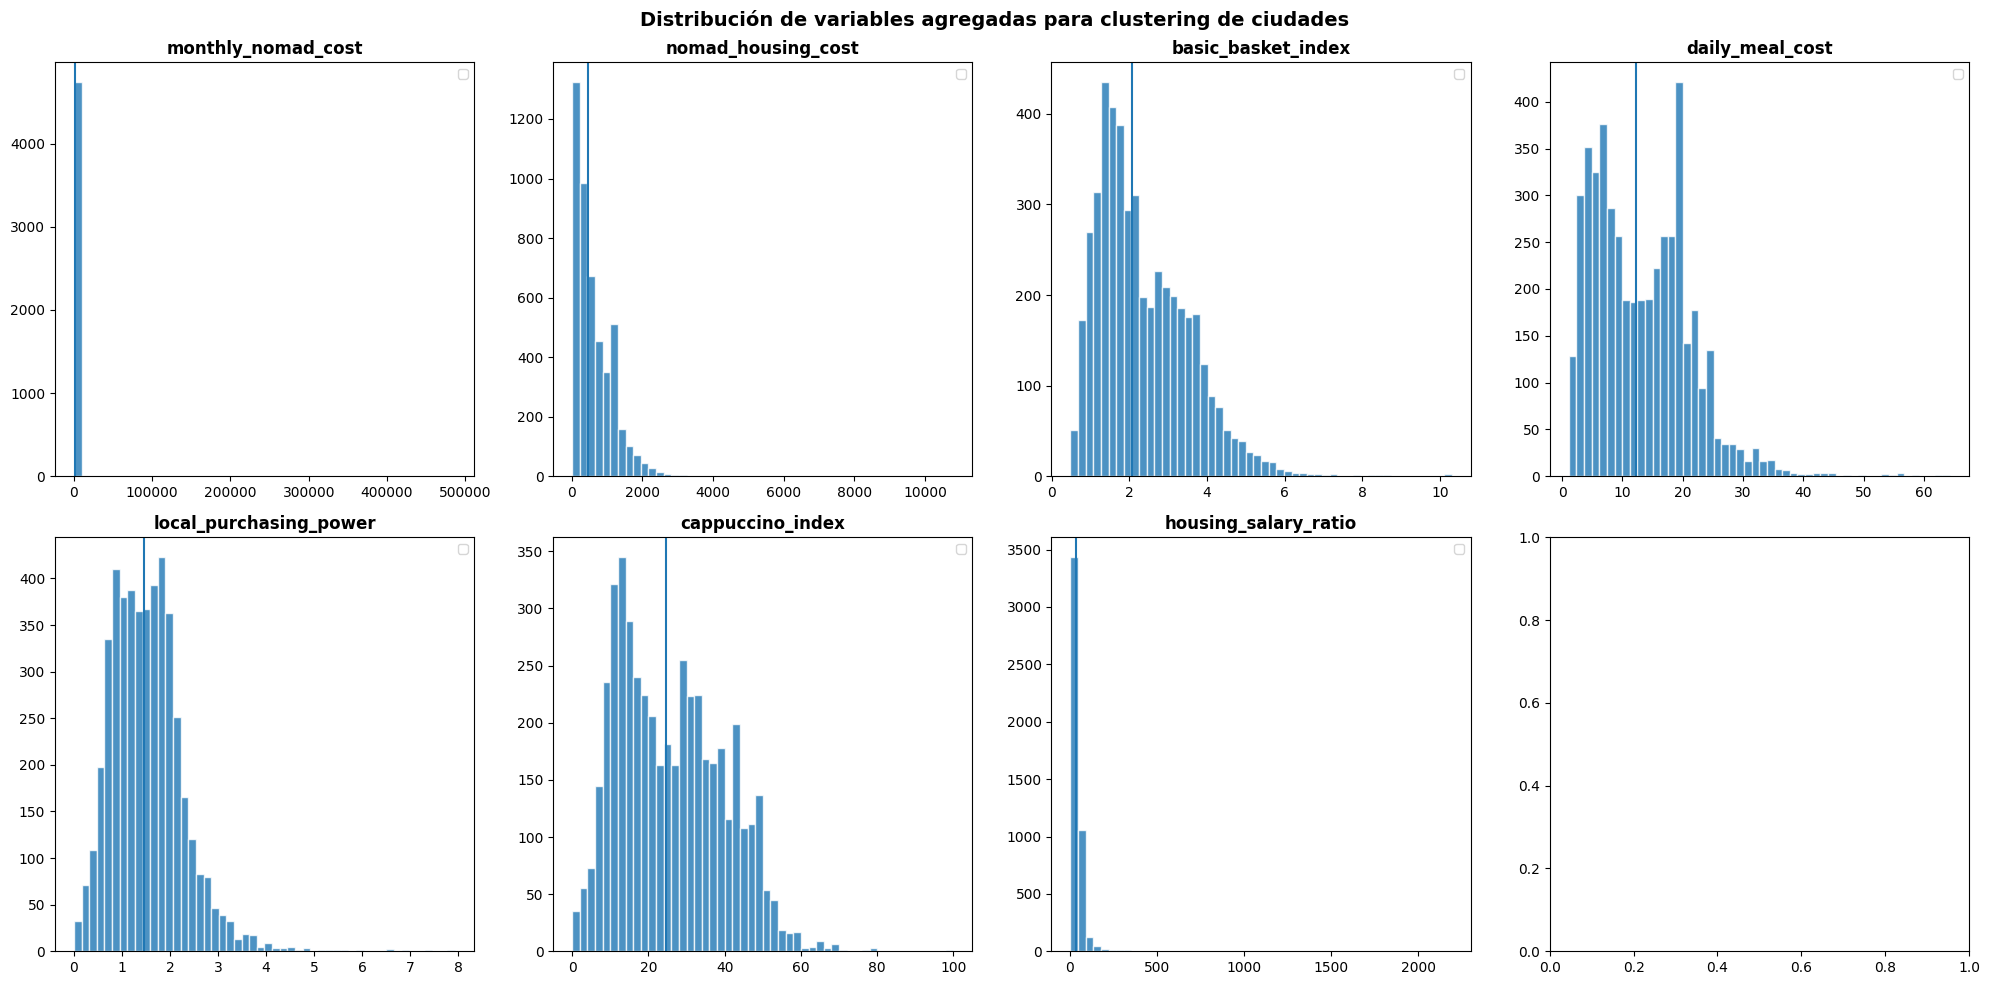

In [20]:
# Distribuciones de las features de clustering

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(nom_features):
    axes[i].hist(df_cities[col], bins=50, edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontweight='bold')
    axes[i].axvline(df_cities[col].median())
    axes[i].legend(fontsize=9)

fig.suptitle('Distribución de variables agregadas para clustering de ciudades', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

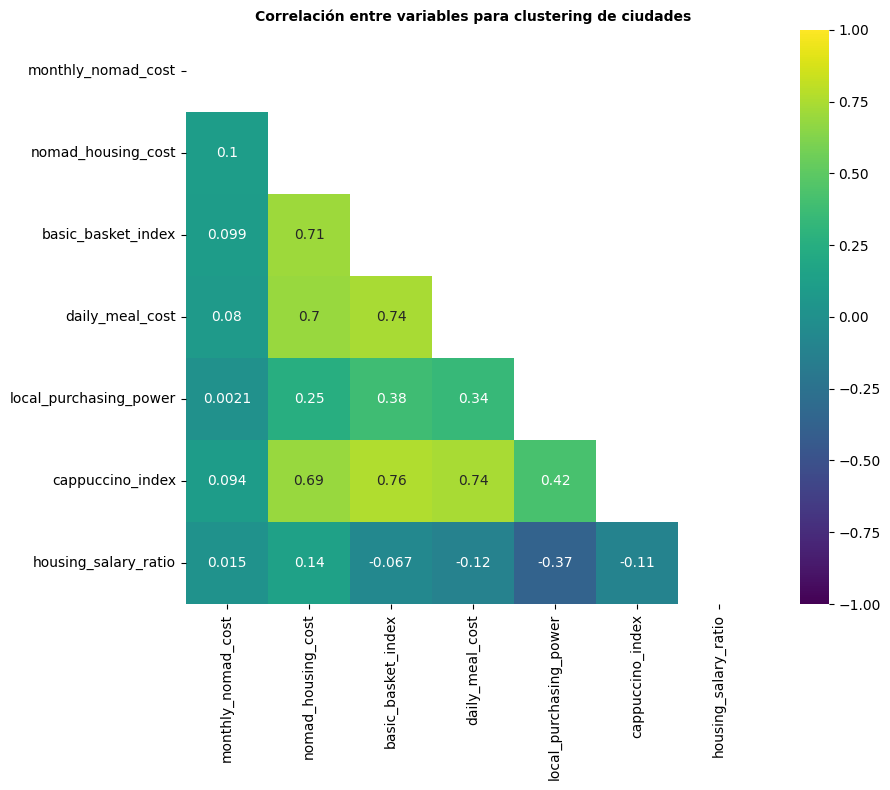

In [21]:
# Correlación entre features para clustering de ciudades

corr_features = df_cities[nom_features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_features))
sns.heatmap(corr_features, 
            mask=mask, 
            annot=True, 
            cmap='viridis',
            center=0, 
            vmin=-1, 
            vmax=1, 
            ax=ax, 
            square=True)
ax.set_title('Correlación entre variables para clustering de ciudades', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

Text(0, 0.5, 'digital_nomad_score')

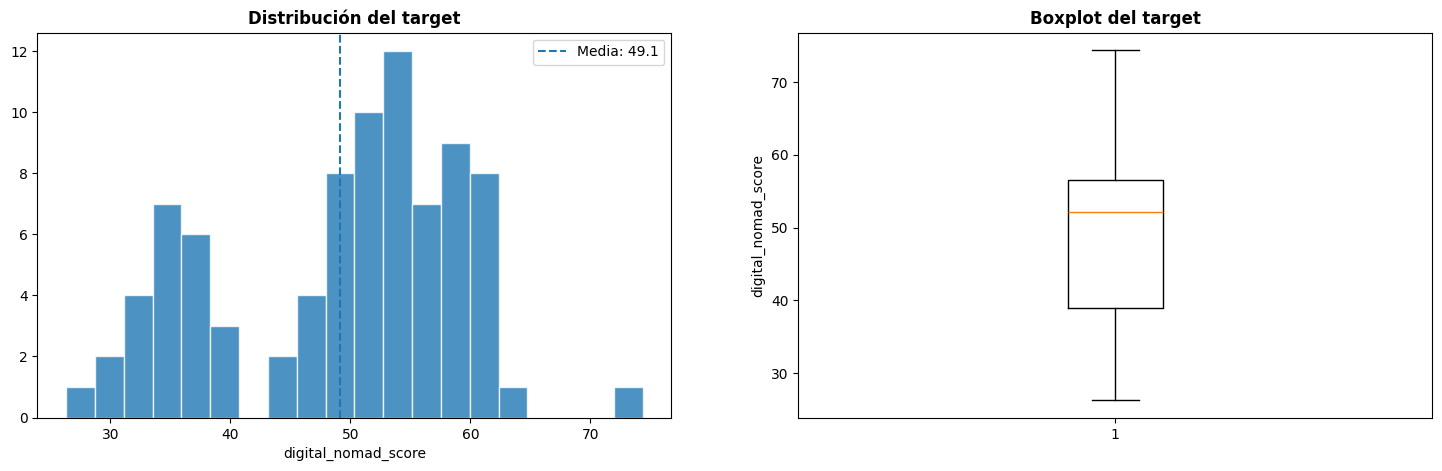

In [22]:
# Análisis del target: digital_nomad_score

target = "digital_nomad_score"

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Distribución con histograma

axes[0].hist(df_circleloop[target], bins=20, edgecolor='white', alpha=0.8)
axes[0].axvline(df_circleloop[target].mean(), linestyle='--', label=f"Media: {df_circleloop[target].mean():.1f}")
axes[0].set_title('Distribución del target', fontweight='bold')
axes[0].set_xlabel(target)
axes[0].legend()

# Boxplot para ver estadíticos y outliers 

axes[1].boxplot(df_circleloop[target], vert=True)
axes[1].set_title('Boxplot del target', fontweight='bold')
axes[1].set_ylabel(target)

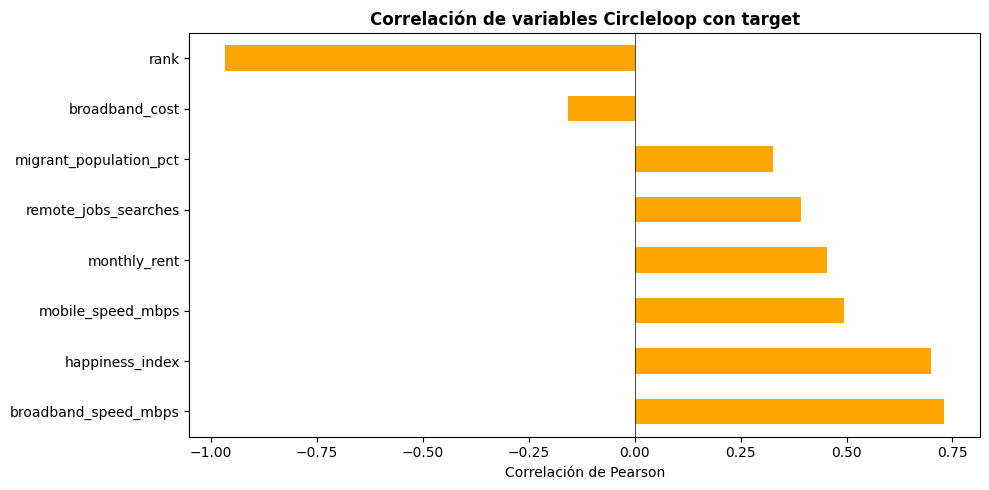

In [23]:
# Correlaciones de variables Circleloop con el target

corr_target = df_circleloop.select_dtypes(include='number').corr()[target].drop(target).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
corr_target.plot(kind='barh', ax=ax, color='orange', edgecolor='none')
ax.set_title('Correlación de variables Circleloop con target', fontweight='bold')
ax.set_xlabel('Correlación de Pearson')
ax.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

### **Tratamiento de variables y clustering de ciudades**

In [31]:
# Preparación de variables para el clustering de ciudades como destinos nómadas digitales
# Creamos un dataframe con todas las variables a partir de una copia de df_cities

df_clustering = df_cities[['city_name', 'country_name', 'continent'] + nom_features].copy()

In [32]:
print(df_clustering[nom_features].isnull().sum().sum()) # No tiene nulos
print(df_clustering.shape) # Tiene todas las ciudades y 10 variables 

0
(4742, 10)


In [33]:
# Quitamos outliers en todas las variables agregadas porque puede deformar los clusters posteriores

for col in nom_features:
    p99 = df_clustering[col].quantile(0.99)
    p01 = df_clustering[col].quantile(0.01)
    df_clustering[col] = df_clustering[col].clip(lower=p01, upper=p99)

In [34]:
# Y ahora las escalamos para normalizar los órdenes de magnitud de todas ellas

scaler_clustering = StandardScaler()
X_clustering = scaler_clustering.fit_transform(df_clustering[nom_features])

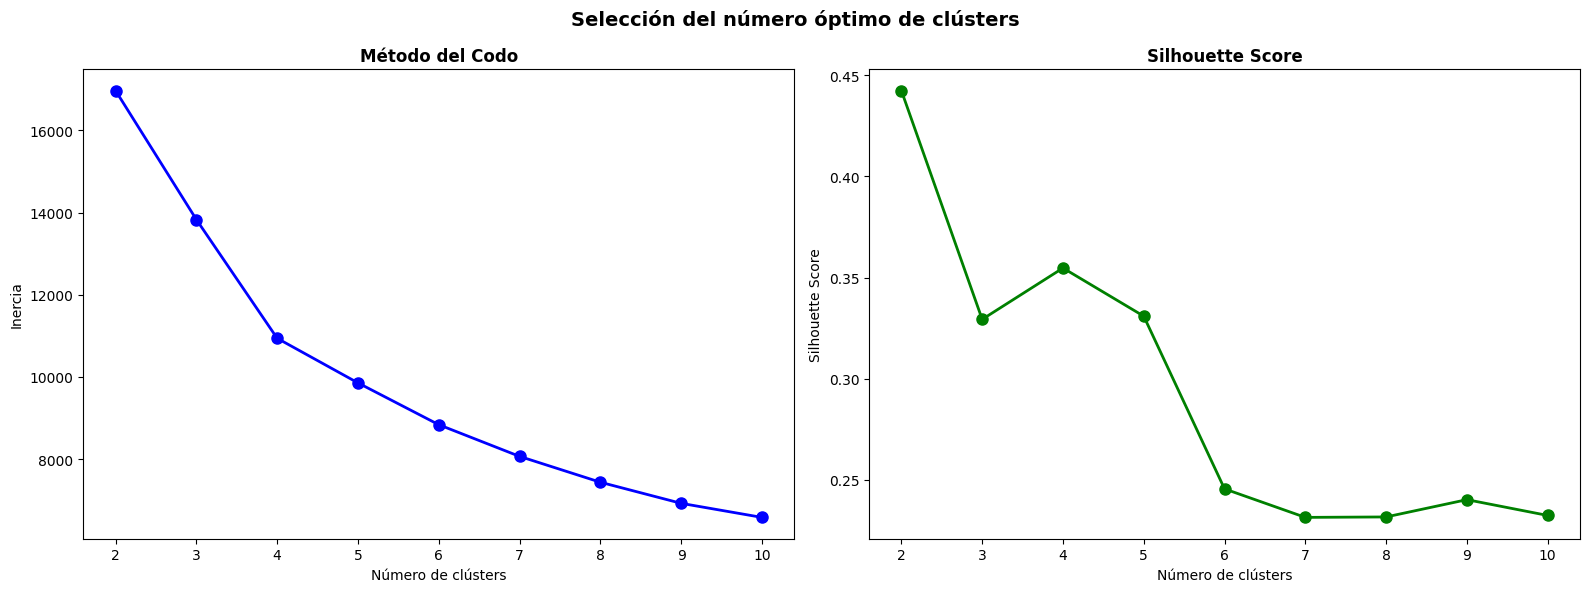

In [38]:
# Método del codo + Silhouette para determinar K óptimo para el etiquetados de ciudades

K_range = range(2, 11)
inertias = []
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_clustering)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_clustering, labels))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Método del codo
axes[0].plot(K_range, inertias, 'o-', color='blue', linewidth=2, markersize=8)
axes[0].set_title('Método del Codo', fontweight='bold')
axes[0].set_xlabel('Número de clústers')
axes[0].set_ylabel('Inercia')
axes[0].set_xticks(list(K_range))

# Silhouette Score
axes[1].plot(K_range, silhouettes, 'o-', color='green', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score', fontweight='bold')
axes[1].set_xlabel('Número de clústers')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(K_range))

fig.suptitle('Selección del número óptimo de clústers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


- Gracias a la gráfica del método del codo podemo sver que un posible número de clústers óptimo es 4. 
- Y en la gráfica de Silhouette Score se puede ver que 2 clústers tienen mejor score, pero el siguiente serían 4 (0.35). 

### **Entrenamos distintos modelos de clustering de ciudades como destino nómada**

In [39]:
# Entrenamos modelo K-Means con K óptimo

best_k = 4 # Este número sale lógicamente del análisis previo

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_clustering['cluster'] = kmeans.fit_predict(X_clustering)

In [44]:
# Analizamos las métricas del modelo 

sil_score = silhouette_score(X_clustering, df_clustering['cluster']) 

print(f'K-Means (K) = {best_k}:')
print(f'Silhouette Score: {sil_score:.2f}')
print(f'\nDistribución de clusters:')
print(df_clustering['cluster'].value_counts().sort_index())

K-Means (K) = 4:
Silhouette Score: 0.35

Distribución de clusters:
cluster
0    1329
1    2179
2    1081
3     153
Name: count, dtype: int64


- Aquí tenemos el reparto de clústers de ciudades a partir del número óptimo evaluado previamente. 
- De total de 4742 ciudades, 1329 están en el clúster 0, otras 2179 en el clúster 1, 1081 en el clúster 2 y 153 en el clúster 3. 